# Q1 - Movement and Distance Analysis: Distance & Demographics

**Author:** Madison Woo

**Dataset:** `40B_zip_long_lat.csv` (https://drive.google.com/file/d/1n92fRXF_BWBSz2-vAPYDsduTz93VxYul/view?usp=drive_link)

**Instruction**: Download the CSV file above and move it to the `ds-chapa-affordable-housing/fa25-team-a/data` folder, then run the cells below

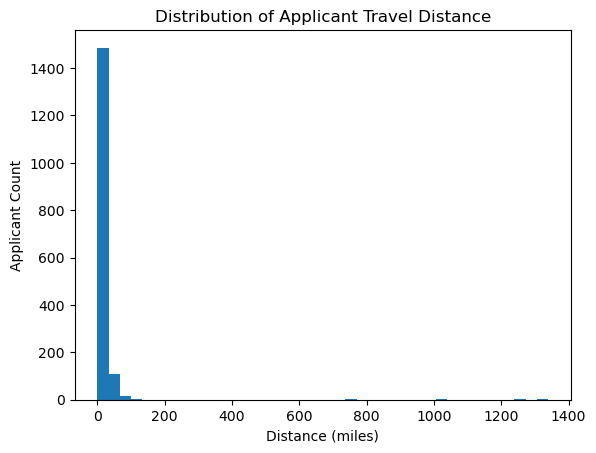

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 

# importing data 
geo = pd.read_csv("../data/40B_zip_long_lat.csv")

# plotting distribution of distance traveled by applicant 
plt.hist(geo['distance_mi'].dropna(), bins = 40)
plt.xlabel("Distance (miles)")
plt.ylabel("Applicant Count")
plt.title("Distribution of Applicant Travel Distance")
plt.show()

A majority of applicants apply to homes somewhat close to their current home, with the average distance for an applicant being 18.8 miles. 

Note: The bins were set to 40 to account for outliers. 

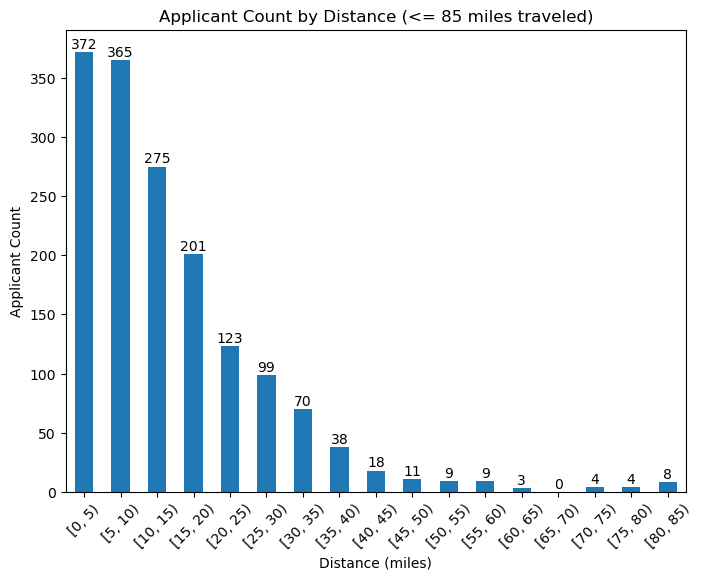

In [22]:
import pandas as pd 
import numpy as np 

# dropping outliers 
geo_dropped = geo[geo['distance_mi'] <= 85].copy()

# get counts of applicants per distance
distance_counts = geo_dropped['distance_mi'].value_counts().sort_index()

# setting bins 
bins = np.arange(0, 90, 5)

# distance bins 
geo_dropped['distance_bin'] = pd.cut(geo_dropped['distance_mi'], bins = bins, right = False)

# counting applicants per bin
distance_counts = geo_dropped['distance_bin'].value_counts().sort_index()

# plot bar chart
for i, v in enumerate(distance_counts):
    plt.text(i, v + 0.5, str(v), ha = 'center', va = 'bottom') 
distance_counts.plot(kind ='bar', figsize = (8,6))
plt.xlabel('Distance (miles)')
plt.ylabel('Applicant Count')
plt.title('Applicant Count by Distance (<= 85 miles traveled)')
plt.xticks(rotation = 45)
plt.show()

I adjusted the graph so that there was a greater focus on the distance travelled excluding outliers. This shows the distance travelled by applicants within Massachusetts only. A majority of applicants apply to properties less than 20 miles from their current home, with most applicants applying to properties 0-5 miles from their current residence. 

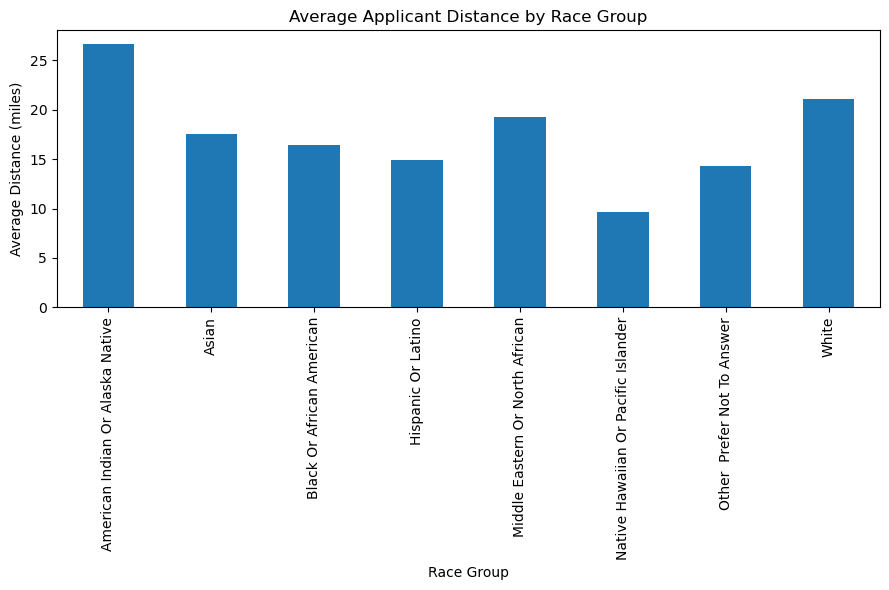

In [28]:
# isolating binary race columns 
race_cols = [
    col for col in geo.columns
    if col.lower().startswith("race_") and geo[col].dropna().isin([0,1]).all()
]

# computing average distance by race 
avg_dist_by_race = (
    geo[race_cols]
    .multiply(geo["distance_mi"], axis = 0)   
    .sum(axis = 0) / geo[race_cols].sum(axis = 0))

# cleaning column names 
clean_names = (
    avg_dist_by_race.index
    .str.replace("race_", "", regex = False)   
    .str.replace("_", " ")                  
    .str.title())          

avg_dist_by_race.index = clean_names                

# plotting distance traveled by race demographics 
avg_dist_by_race.plot(kind = "bar", figsize = (9, 6))
plt.title("Average Applicant Distance by Race Group")
plt.ylabel("Average Distance (miles)")
plt.xlabel("Race Group")
plt.tight_layout()
plt.show()

Applicants who are American Indian or Alaska Native apply to further homes, followed by Middle Eastern or North African and White applicants. 

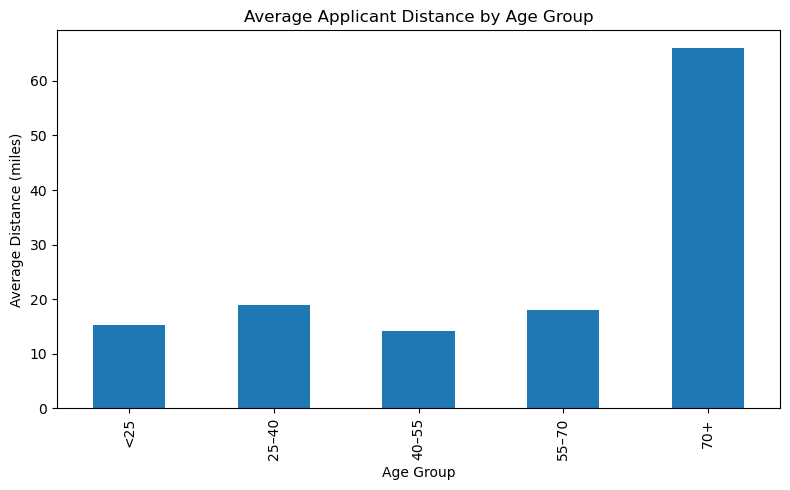

In [13]:
# age groups 
geo['age_group'] = pd.cut (geo['age'], bins = [0, 25, 40, 55, 70, 100], 
                           labels = ["<25", "25–40", "40–55", "55–70", "70+"])

# mean distance for each age group 
age_distance = geo.groupby("age_group")["distance_mi"].mean()

# plot
plt.figure(figsize = (8, 5))
age_distance.plot(kind = "bar")
plt.xlabel("Age Group")
plt.ylabel("Average Distance (miles)")
plt.title("Average Applicant Distance by Age Group")
plt.tight_layout()
plt.show()

Applicants who are 70+ years of age appear to be applying to farther properties from their current home. 